# Introducción

El presente estudio trata el desarrollo de un modelo predictivo que permita estimar el volumen de exportaciones del Top 5 de productos en un horizonte de 12 meses, mediante el uso de técnica/s de Machine Learning analizando datos historicos. Este enfoque busca brindar información valiosa para la toma de decisiones de las autoridades y los actores involucrados en el comercio exterior, permitiendo la identificación de oportunidades y desafíos en el mercado internacional y la formulación de estrategias adecuadas para enfrentarlos.

# Objetivos

## Objetivo General

Desarrollar un modelo predictivo basado en Machine Learning para estimar el crecimiento o decrecimiento del volumen de exportaciones del Top 5 histórico de productos más exportados desde Ecuador a Estados Unidos en el siguiente año.

## Objetivos Específicos

- Realizar un análisis exploratorio de la base de datos proporcionada por el MPCEIP para comprender las características de las exportaciones y sus cambios a lo largo de los años, identificando patrones y tendencias relevantes en el Top 5 histórico de productos más exportados.
- Preprocesar y preparar los datos para su uso en el desarrollo del modelo predictivo, llevando a cabo tareas de limpieza, transformación y selección de variables relevantes.
- Crear un modelo con técnicas de Machine Learning que permita predecir el crecimiento o decrecimiento del volumen en toneladas de las exportaciones del Top 5 histórico de productos exportados a Estados Unidos.
- Definir un método o técnica conveniente que permita realizar las predicciones con los datos y variables provistos.


# Alcance

El presente estudio se enfoca en analizar y predecir el crecimiento o decrecimiento del volumen de exportaciones del Top 5 histórico de productos más exportados desde Ecuador a Estados Unidos, utilizando los datos proporcionados por el Ministerio de Producción, Comercio Exterior, Inversiones y Pesca (MPCEIP) desde el año 2001 hasta la fecha de corte de conocimiento en 2021. El alcance del estudio abarca los siguientes aspectos:


1. La investigación se limita al análisis de las exportaciones de los cinco productos principales en términos de cantidad exportada (en toneladas), sin considerar otros productos o variables económicas adicionales que puedan influir en el comercio exterior.

2. Se analizarán exclusivamente las exportaciones realizadas desde Ecuador hacia Estados Unidos, sin incluir otros destinos o relaciones comerciales internacionales.

3. El modelo predictivo desarrollado tiene como objetivo estimar el volumen de exportaciones del Top 5 histórico de productos para el siguiente año, no abordando predicciones a largo plazo o tendencias futuras más allá de ese periodo.

4. El estudio no pretende ofrecer un análisis exhaustivo de las causas o factores que influyen en el crecimiento o decrecimiento de las exportaciones, sino que se centra en la aplicación de técnicas de Machine Learning para predecir el comportamiento de las exportaciones en base a los datos históricos disponibles.

5. Las conclusiones y recomendaciones derivadas del estudio estarán enfocadas en la toma de decisiones relacionadas con la producción, inversión y estrategias comerciales en el contexto del comercio exterior entre Ecuador y Estados Unidos, sin entrar en detalles específicos de políticas gubernamentales o acciones a nivel empresarial.

# Metodologia

El presente estudio seguirá un enfoque estructurado basado en los pasos del aprendizaje automático, que se integran con las fases CRISP-DM (ver @fig-crispdm), para desarrollar un modelo predictivo del crecimiento o decrecimiento del volumen de exportaciones del Top 5 histórico de productos más exportados desde Ecuador a Estados Unidos. A continuación, se detallan las etapas del proceso las cuales se integran y las herramientas que se utilizarán en cada paso:
```{mermaid}
flowchart LR
  A[Recolección] --> B[Preparación] --> C[Selección] --> D[Entrenamiento] --> E[Evaluación] --> F[Afinamiento]--> G[Predicción]
```

![Tareas genéricas y resultados del modelo de referencia CRISP-DM [@chapman2000crisp]](/imgs/crispdm.png){#fig-crispdm}

In [5]:
# Carga de librerias y ajustes
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format

# Recolección de datos

Los datos históricos de exportación serán obtenidos de la base de datos proporcionada por el Ministerio de Producción, Comercio Exterior, Inversiones y Pesca (MPCEIP), disponible en formato CSV [en la página de datos abiertos.](https://www.datosabiertos.gob.ec/dataset/exportaciones-a-estados-unidos-de-america/resource/0335c16b-6320-45c9-8409-75890e38537c)

In [7]:
# Carga de datos
df = pd.read_csv("mpceip_exportaciones-eeuu_2021_11.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109720 entries, 0 to 109719
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Año                           109720 non-null  object 
 1   Mes                           103503 non-null  float64
 2   País Destino                  103503 non-null  object 
 3   Capítulo                      103503 non-null  float64
 4   4D                            103503 non-null  float64
 5   Producto Principal (Nivel 4)  103503 non-null  object 
 6   6D                            103503 non-null  float64
 7   8D                            103503 non-null  float64
 8   Tradicional/No tradicional    103503 non-null  object 
 9   No Petrolero/Petrolero        103503 non-null  object 
 10  Código Subpartida             103503 non-null  float64
 11  Export FOB (miles)            103503 non-null  float64
 12  Toneladas                     103503 non-nul

# Preparación de datos

In [9]:
df.head()

,Año,Mes,País Destino,Capítulo,4D,Producto Principal (Nivel 4),6D,8D,Tradicional/No tradicional,No Petrolero/Petrolero,Código Subpartida,Export FOB (miles),Toneladas
0,2021,1.00,ESTADOS UNIDOS,1.00,101.00,Animales Vivos No Para Alimentación,"10,129.00","1,012,990.00",NO TRADICIONAL,No Petrolero,"101,299,000.00",1.50,0.43
1,2021,1.00,ESTADOS UNIDOS,1.00,106.00,Animales Vivos No Para Alimentación,"10,620.00","1,062,000.00",NO TRADICIONAL,No Petrolero,"106,200,000.00",120.00,14.00
2,"2021,01,ESTADOS UNIDOS,02,0208,""Carne, Leche Y...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"2021,01,ESTADOS UNIDOS,02,0208,""Carne, Leche Y...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,1.00,ESTADOS UNIDOS,3.00,301.00,Animales Vivos No Para Alimentación,"30,199.00","3,019,919.00",NO TRADICIONAL,No Petrolero,"301,991,990.00",23.67,1.80


In [10]:
df.iloc[2,0]

'2021,01,ESTADOS UNIDOS,02,0208,"Carne, Leche Y Elaborados",020810,02081000,NO TRADICIONAL,No Petrolero,0208100000,0.21,0.3'

## Limpieza

::: {.callout-note}
El problema en la tercera y cuarta línea del dataframe es que los datos están mal formateados y no siguen la estructura de las demás filas. Parece que todos los valores en estas dos filas están concatenados en una sola cadena de texto en la columna "Año", en lugar de estar distribuidos en sus respectivas columnas.
:::

In [12]:
# Verificando el problema a nivel global
df[df['Mes'].isna()].shape

(6217, 13)

El problema se repite a lo largo del dataset, es necesario resolver esta problematica de manera sistematica. Una solución es utilizar una expresión regular para hacer una división inteligente de la cadena de texto. Para esto implementamos la funcion `corregir_fila_mal_formateada` en donde:

* La función `re.split()` divide la cadena en función de las comas, pero ignoramos las comas que se encuentran dentro de las comillas dobles. 
* Luego, utilizamos una comprensión de lista y la función `re.sub()` para eliminar las comillas dobles de cada elemento en la lista componentes. La expresión regular `r'^"|"$' en re.sub()` coincide con las comillas dobles al principio **(^")** o al final **("$)** de una cadena.
* Finalmente, iteramos a través de las filas del dataframe y verificamos si cada fila está mal formateada (por ejemplo, si el valor en la columna 'Mes' es NaN). Si es así, aplicamos la función `corregir_fila_mal_formateada()` y reemplazamos la correccion realizada por la fila mal formateada.

In [14]:
def corregir_fila_mal_formateada(fila_mal_formateada):
    # Dividir la fila mal formateada en sus componentes utilizando una expresión regular
    componentes = re.split(r',\s*(?=(?:[^"]*"[^"]*")*[^"]*$)', fila_mal_formateada)
    componentes = [re.sub(r'^"|"$', '', componente) for componente in componentes]
    
    return componentes

for idx, fila in df.iterrows():
    if pd.isna(fila['Mes']):
        fila_corregida = corregir_fila_mal_formateada(fila['Año'])
        df.iloc[idx] = fila_corregida

Verificamos si el problema fue solventado de manera correcta y vemos que los valores ahora estan en los campos correctos

In [16]:
df.head()

,Año,Mes,País Destino,Capítulo,4D,Producto Principal (Nivel 4),6D,8D,Tradicional/No tradicional,No Petrolero/Petrolero,Código Subpartida,Export FOB (miles),Toneladas
0,2021,1.00,ESTADOS UNIDOS,1.00,101.00,Animales Vivos No Para Alimentación,"10,129.00","1,012,990.00",NO TRADICIONAL,No Petrolero,"101,299,000.00",1.50,0.43
1,2021,1.00,ESTADOS UNIDOS,1.00,106.00,Animales Vivos No Para Alimentación,"10,620.00","1,062,000.00",NO TRADICIONAL,No Petrolero,"106,200,000.00",120.00,14.00
2,2021,01,ESTADOS UNIDOS,02,0208,"Carne, Leche Y Elaborados",020810,02081000,NO TRADICIONAL,No Petrolero,0208100000,0.21,0.3
3,2021,01,ESTADOS UNIDOS,02,0208,"Carne, Leche Y Elaborados",020890,02089000,NO TRADICIONAL,No Petrolero,0208900000,4.675,0.8
4,2021,1.00,ESTADOS UNIDOS,3.00,301.00,Animales Vivos No Para Alimentación,"30,199.00","3,019,919.00",NO TRADICIONAL,No Petrolero,"301,991,990.00",23.67,1.80


In [17]:
df[df['Mes'].isna()].shape

(0, 13)

## Selección de características
En esta parte se eliminan las columnas que son irrelevantes o redundantes, para el problema. Para esto seleccionamos solamente las caracteristicas que vamos a utilizar para construir el modelo. Incorporar variables adicionales al modelo predictivo puede mejorar su capacidad para hacer predicciones precisas y capturar la dinámica subyacente de los datos. Dado el conjunto de datos estan son las variables que podrían ser útiles en el modelo:

- **Producto Principal (Nivel 4)**: Esta variable categórica proporciona información sobre los diferentes productos exportados. Incluir esta variable en tu modelo puede ayudar a capturar la variación en el volumen de exportaciones (toneladas) para diferentes productos a lo largo del tiempo.

- **Tradicional/No tradicional**: Esta variable categórica indica si un producto es tradicional o no tradicional en términos de exportaciones. Al incluir esta variable en el modelo, podrías capturar diferencias en la evolución de las exportaciones de productos tradicionales y no tradicionales.

 - **No Petrolero/Petrolero**: Esta variable categórica distingue entre productos petroleros y no petroleros. Al incorporar esta variable en el modelo, podrías capturar diferencias en el comportamiento de las exportaciones de productos petroleros y no petroleros.

- **Fecha (año y mes)**: La estructura de tiempo es fundamental para capturar la evolución de las exportaciones a lo largo del tiempo y predecir con precisión.
 
- **Toneladas**: Esta variable representa el volumen de las exportaciones en términos de toneladas. Es la variable objetivo que se pronosticara pra el siguiente año.

- **Precio**: No es un campo que viene de manera explicita en el dataset pero se lo puede calcular de manera implicita dividiendo `Export FOB (miles)` por la columna `Toneladas`. El precio puede ser un factor importante en un modelo de predicción de exportaciones, ya que puede influir en la cantidad de bienes que se exportan. Por ejemplo, si el precio de un producto aumenta, podría haber una disminución en la demanda y, por lo tanto, en la cantidad exportada. Por otro lado, si el precio disminuye, podría haber un aumento en la demanda y en las exportaciones.

## Tipos de datos

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109720 entries, 0 to 109719
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Año                           109720 non-null  object
 1   Mes                           109720 non-null  object
 2   País Destino                  109720 non-null  object
 3   Capítulo                      109720 non-null  object
 4   4D                            109720 non-null  object
 5   Producto Principal (Nivel 4)  109720 non-null  object
 6   6D                            109720 non-null  object
 7   8D                            109720 non-null  object
 8   Tradicional/No tradicional    109720 non-null  object
 9   No Petrolero/Petrolero        109720 non-null  object
 10  Código Subpartida             109720 non-null  object
 11  Export FOB (miles)            109720 non-null  object
 12  Toneladas                     109720 non-null  object
dtyp

In [21]:
tipos_de_datos = {col:tipo for col, tipo in zip(df.columns[[0,1,5,8,9,11,12]], [int, int, str, str, str, float, float])}
df = df.astype(tipos_de_datos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109720 entries, 0 to 109719
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Año                           109720 non-null  int32  
 1   Mes                           109720 non-null  int32  
 2   País Destino                  109720 non-null  object 
 3   Capítulo                      109720 non-null  object 
 4   4D                            109720 non-null  object 
 5   Producto Principal (Nivel 4)  109720 non-null  object 
 6   6D                            109720 non-null  object 
 7   8D                            109720 non-null  object 
 8   Tradicional/No tradicional    109720 non-null  object 
 9   No Petrolero/Petrolero        109720 non-null  object 
 10  Código Subpartida             109720 non-null  object 
 11  Export FOB (miles)            109720 non-null  float64
 12  Toneladas                     109720 non-nul

## Transformación de datos
### Creando la variable `Precio`

In [23]:
# Variable precio
df['Precio Unitario'] = df['Export FOB (miles)'] / df['Toneladas']
# Seleccion de variables
df = df[['Año', 'Mes', 'Producto Principal (Nivel 4)', 'Tradicional/No tradicional', 'No Petrolero/Petrolero', 'Precio Unitario', 'Toneladas']]

### Creando la variable `Fecha`

Para trabajar en un problema de series temporales, es aconsejable combinar las columnas de 'Año' y 'Mes' en una única columna de tipo `datetime` en lugar de mantenerlas por separado. Esto te permitirá aprovechar mejor las funciones de análisis y manipulación de series temporales disponibles en bibliotecas como pandas y facilitará el análisis y la modelización de los datos. [@atwan2022time]

In [25]:
# Convertir las columnas de 'Año' y 'Mes' en una columna de tipo 'datetime'
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes'].astype(str))

# Eliminar las columnas 'Año' y 'Mes'
df = df.drop(['Año', 'Mes'], axis=1)

# Establecer 'Fecha' como índice del dataframe si se desea
df = df.set_index('Fecha')
df

,Producto Principal (Nivel 4),Tradicional/No tradicional,No Petrolero/Petrolero,Precio Unitario,Toneladas
Fecha,,,,,
2021-01-01,Animales Vivos No Para Alimentación,NO TRADICIONAL,No Petrolero,3.49,0.43
2021-01-01,Animales Vivos No Para Alimentación,NO TRADICIONAL,No Petrolero,8.57,14.00
2021-01-01,"Carne, Leche Y Elaborados",NO TRADICIONAL,No Petrolero,0.70,0.30
2021-01-01,"Carne, Leche Y Elaborados",NO TRADICIONAL,No Petrolero,5.84,0.80
2021-01-01,Animales Vivos No Para Alimentación,NO TRADICIONAL,No Petrolero,13.15,1.80
...,...,...,...,...,...
2001-12-01,Otras Mercancías,NO TRADICIONAL,No Petrolero,28.37,0.22
2001-12-01,Otras Mercancías,NO TRADICIONAL,No Petrolero,20.54,0.32
2001-12-01,Otras Mercancías,NO TRADICIONAL,No Petrolero,10.81,1.17


## Identificación del TOP 5 histórico de productos

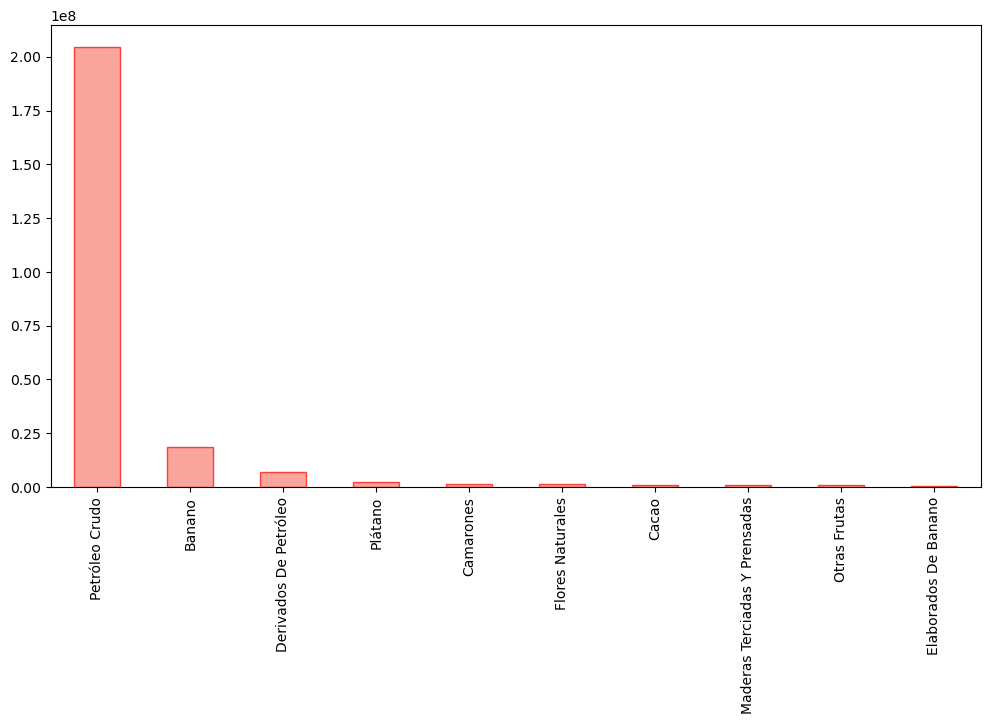

In [27]:
#| label: fig-top
#| fig-cap: Productos más exportados en el período 2001-2021

df.groupby('Producto Principal (Nivel 4)')['Toneladas'].sum().sort_values(
    ascending = False)[:10].plot(
    kind='bar', color='salmon', edgecolor='red', alpha=0.7, figsize=(12,6), xlabel='')
plt.show()

In [28]:
# Filtrar el dataset para incluir solo el Top 5 histórico de productos
top_5_productos = df.groupby('Producto Principal (Nivel 4)')['Toneladas'].sum().sort_values(ascending = False)[:5].index
pd.Series(top_5_productos, index=range(1,6))

1           Petróleo Crudo
2                   Banano
3    Derivados De Petróleo
4                  Plátano
5                Camarones
Name: Producto Principal (Nivel 4), dtype: object

## Agrupando por una escala temporal

Se tiene **109720 registros** en el conjunto de datos que cubren el período de 2001 a 2002, estamos lidiando con una gran cantidad de detalles y transacciones individuales. Para facilitar el análisis de las tendencias a lo largo del tiempo, es mejor considerar la posibilidad de agrupar y agregar los datos.

Al agrupar por mes, se podrá analizar las tendencias y patrones en las exportaciones de productos en una escala temporal más granular [@hyndman2018forecasting]. Esto puede ser útil para identificar patrones estacionales, detectar cambios repentinos en las exportaciones o identificar periodos de crecimiento o disminución en las exportaciones de productos específicos.

::: {.callout-important}
La volatilidad en los datos es alta, ya que las fluctuaciones de las observaciones son más pronunciadas que las tendencias a largo plazo, esto dificulta la identificación de patrones claros en los datos, también se puede probar una escala temporal diferente, como trimestral o anual, tal como se observa en la @fig-escalas, para suavizar la variabilidad a corto plazo y centrarnos en las tendencias generales.
:::

In [30]:
# Filtrar el DataFrame original para mantener solo los 5 productos principales
df_top_5 = df[df['Producto Principal (Nivel 4)'].isin(top_5_productos)]

# Calcula el número total de observaciones para cada producto
total_observaciones = df_top_5.groupby('Producto Principal (Nivel 4)').size()

# Calcular el el número total de observaciones por mes para cada producto
observaciones_mensuales = df.reset_index().groupby(
    [pd.Grouper(key='Fecha', freq='M'), 'Producto Principal (Nivel 4)']).sum().reset_index().groupby(
    'Producto Principal (Nivel 4)').size().loc[top_5_productos]

# Calcular el el número total de observaciones por trimstre para cada producto
observaciones_trimestrales = df.reset_index().groupby(
    [pd.Grouper(key='Fecha', freq='Q'), 'Producto Principal (Nivel 4)']).sum().reset_index().groupby(
    'Producto Principal (Nivel 4)').size().loc[top_5_productos]

observaciones = pd.concat([total_observaciones, observaciones_mensuales, observaciones_trimestrales], axis=1)
observaciones.columns = ['Totales', 'Mensuales', 'Trimestrales']
observaciones

,Totales,Mensuales,Trimestrales
Producto Principal (Nivel 4),,,
Banano,680,249,83
Camarones,1245,249,83
Derivados De Petróleo,348,200,82
Petróleo Crudo,249,249,83
Plátano,254,249,83


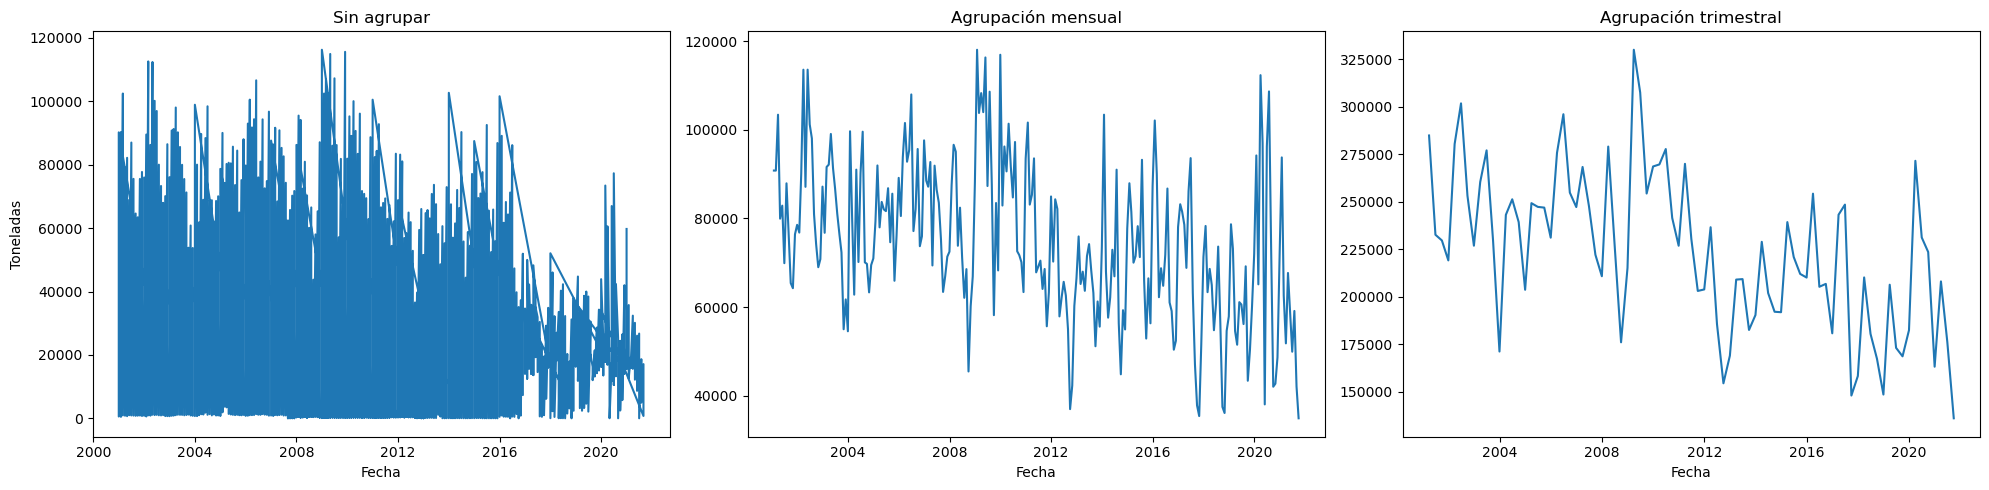

In [31]:
#| label: fig-escalas
#| fig-cap: Diferentes escalas en una serie de tiempo

# Sin agrupar
sin_agrupar = df[(df['Producto Principal (Nivel 4)'] == 'Banano')]['Toneladas']

# Agrupación mensual
agrupacion_mensual = (df[(df['Producto Principal (Nivel 4)'] == 'Banano')]
                      .resample('M')['Toneladas'].sum())

# Agrupación trimestral
agrupacion_trimestral = (df[(df['Producto Principal (Nivel 4)'] == 'Banano')]
                         .resample('Q')['Toneladas'].sum())

# Creación de subgráficos
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharey=False)

# Sin agrupar
axs[0].plot(sin_agrupar)
axs[0].set_title('Sin agrupar')
axs[0].set_xlabel('Fecha')
axs[0].set_ylabel('Toneladas')

# Agrupación mensual
axs[1].plot(agrupacion_mensual)
axs[1].set_title('Agrupación mensual')
axs[1].set_xlabel('Fecha')

# Agrupación trimestral
axs[2].plot(agrupacion_trimestral)
axs[2].set_title('Agrupación trimestral')
axs[2].set_xlabel('Fecha')

# Ajuste de espaciado y visualización
plt.tight_layout()
plt.show()

In [32]:
df_agrupado = df.reset_index().groupby([pd.Grouper(key='Fecha', freq='M'), 'Producto Principal (Nivel 4)', 'Tradicional/No tradicional', 'No Petrolero/Petrolero']).sum().reset_index(level=[1,2,3])
dfm = df_agrupado[df_agrupado['Producto Principal (Nivel 4)'].isin(top_5_productos)]
dfm#df.index = df.index.to_period('M')

,Producto Principal (Nivel 4),Tradicional/No tradicional,No Petrolero/Petrolero,Precio Unitario,Toneladas
Fecha,,,,,
2001-01-31,Banano,TRADICIONAL,No Petrolero,0.64,"90,784.18"
2001-01-31,Camarones,TRADICIONAL,No Petrolero,31.75,"1,517.49"
2001-01-31,Derivados De Petróleo,NO TRADICIONAL,Petrolero,132.59,"39,070.00"
2001-01-31,Petróleo Crudo,TRADICIONAL,Petrolero,0.13,"401,801.40"
2001-01-31,Plátano,TRADICIONAL,No Petrolero,0.22,"5,936.01"
...,...,...,...,...,...
2021-09-30,Banano,TRADICIONAL,No Petrolero,2.06,"34,891.55"
2021-09-30,Camarones,TRADICIONAL,No Petrolero,99.09,"12,783.36"
2021-09-30,Derivados De Petróleo,NO TRADICIONAL,Petrolero,72.65,"141,861.01"


# Análisis exploratorio de datos

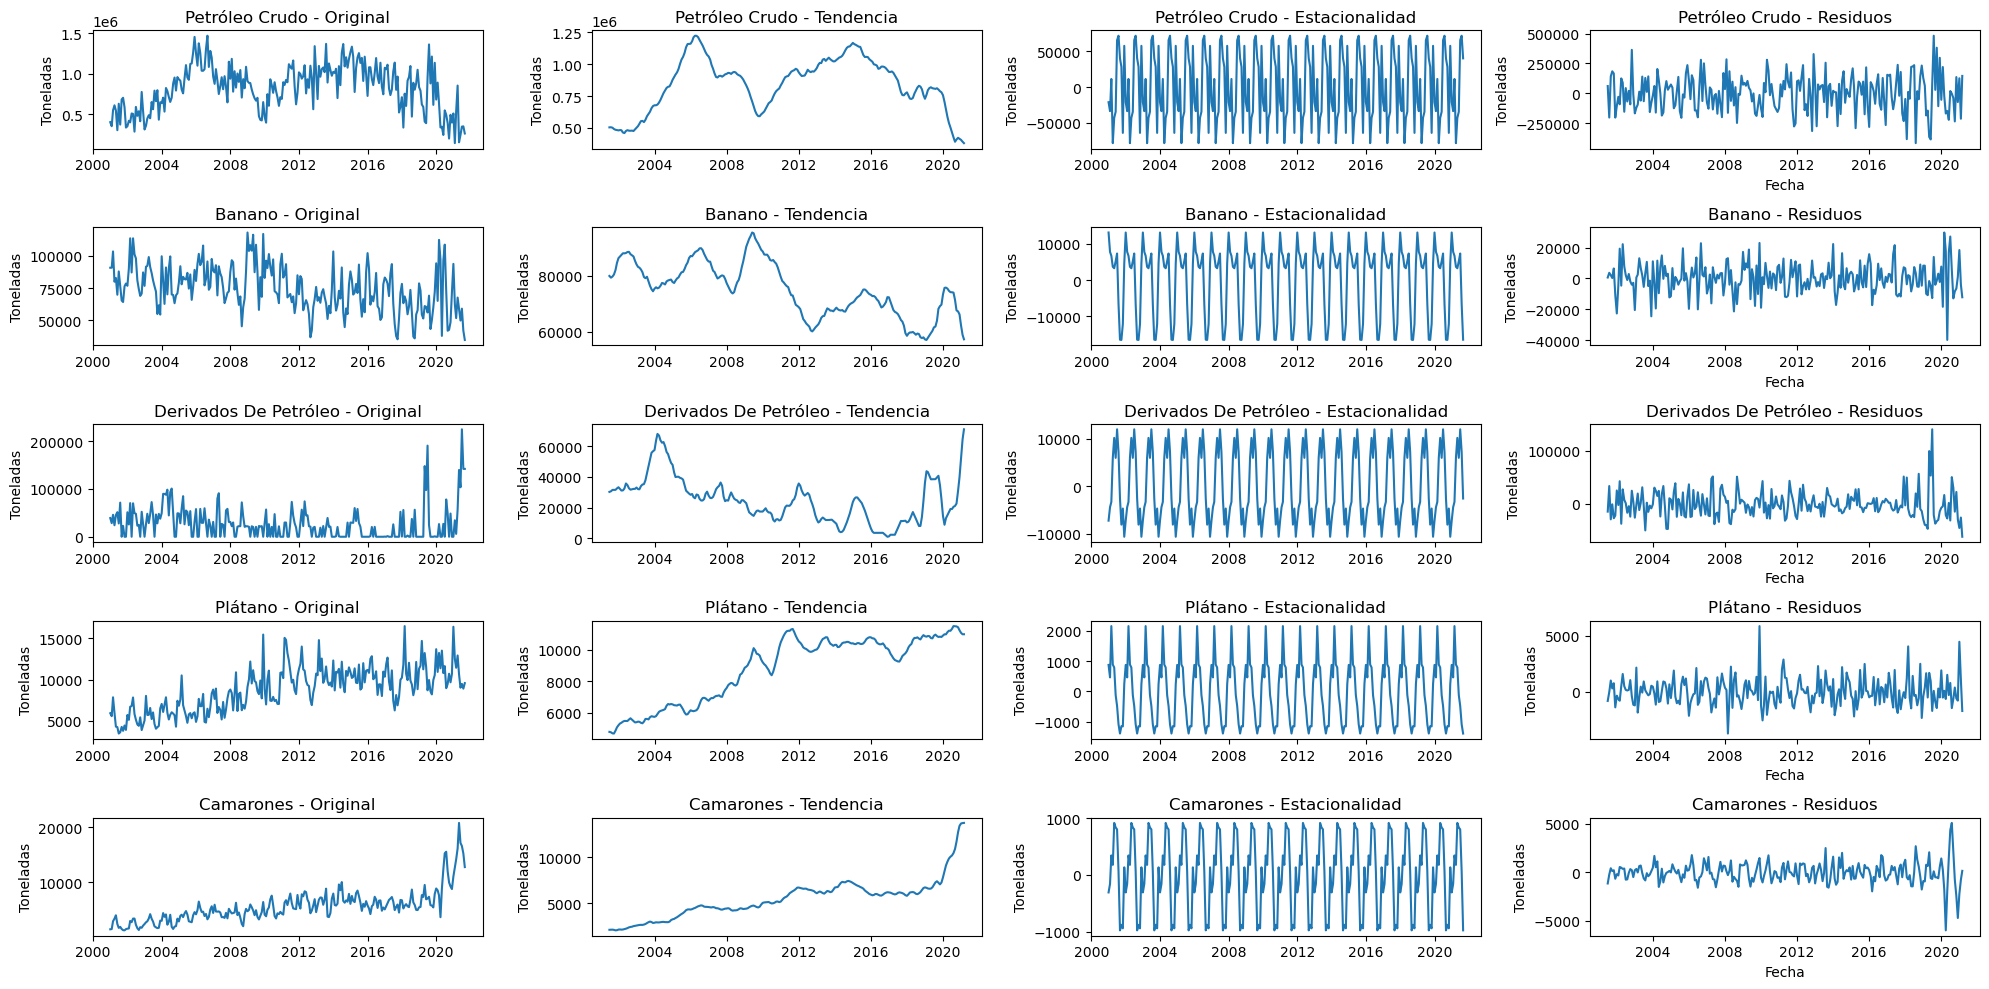

In [51]:
#| label: fig-descompose
#| fig-cap: Descomposición de componentes

# Creación de subgráficos
fig, axs = plt.subplots(5, 4, figsize=(20, 10))

for i, producto in enumerate(top_5_productos):
    # Filtrar el producto y agregar por mes
    data_producto = (dfm[(dfm['Producto Principal (Nivel 4)'] == producto)]
                     .resample('M')['Toneladas'].sum())

    # Ajusta el índice para que sea el inicio de cada mes
    data_producto.index = data_producto.index.to_period('M').to_timestamp()
    
    # Descomposición estacional
    descomposicion = seasonal_decompose(data_producto, model='additive')
    
    # Graficar descomposición
    axs[i, 0].plot(data_producto)
    axs[i, 0].set_title(f'{producto} - Original')
    axs[i, 0].set_ylabel('Toneladas')
    
    axs[i, 1].plot(descomposicion.trend)
    axs[i, 1].set_title(f'{producto} - Tendencia')
    axs[i, 1].set_ylabel('Toneladas')
    
    axs[i, 2].plot(descomposicion.seasonal)
    axs[i, 2].set_title(f'{producto} - Estacionalidad')
    axs[i, 2].set_ylabel('Toneladas')
    
    axs[i, 3].plot(descomposicion.resid)
    axs[i, 3].set_title(f'{producto} - Residuos')
    axs[i, 3].set_ylabel('Toneladas')
    axs[i, 3].set_xlabel('Fecha')

# Ajuste de espaciado y visualización
plt.tight_layout()
plt.show()

Recortar un subconjunto de años de un conjunto de datos para capturar la tendencia y estacionalidad de manera más clara puede ser útil en ciertas situaciones, como por ejemplo:

Cambio estructural
: Si ha habido un cambio estructural en la serie de tiempo que ha provocado cambios significativos en la tendencia y la estacionalidad, puede ser útil centrarse en un período más reciente que refleje mejor la situación actual.

Datos poco confiables o ruidosos
: Si los datos en algunos períodos son de baja calidad o contienen mucho ruido, puede ser beneficioso excluir esos períodos para mejorar la calidad de los datos y la precisión de las predicciones.

Cambio en las políticas o regulaciones
: Si hubo cambios significativos en las políticas o regulaciones que afectan la serie de tiempo, puede ser útil centrarse en el período posterior a estos cambios para capturar la tendencia y estacionalidad de manera más precisa.

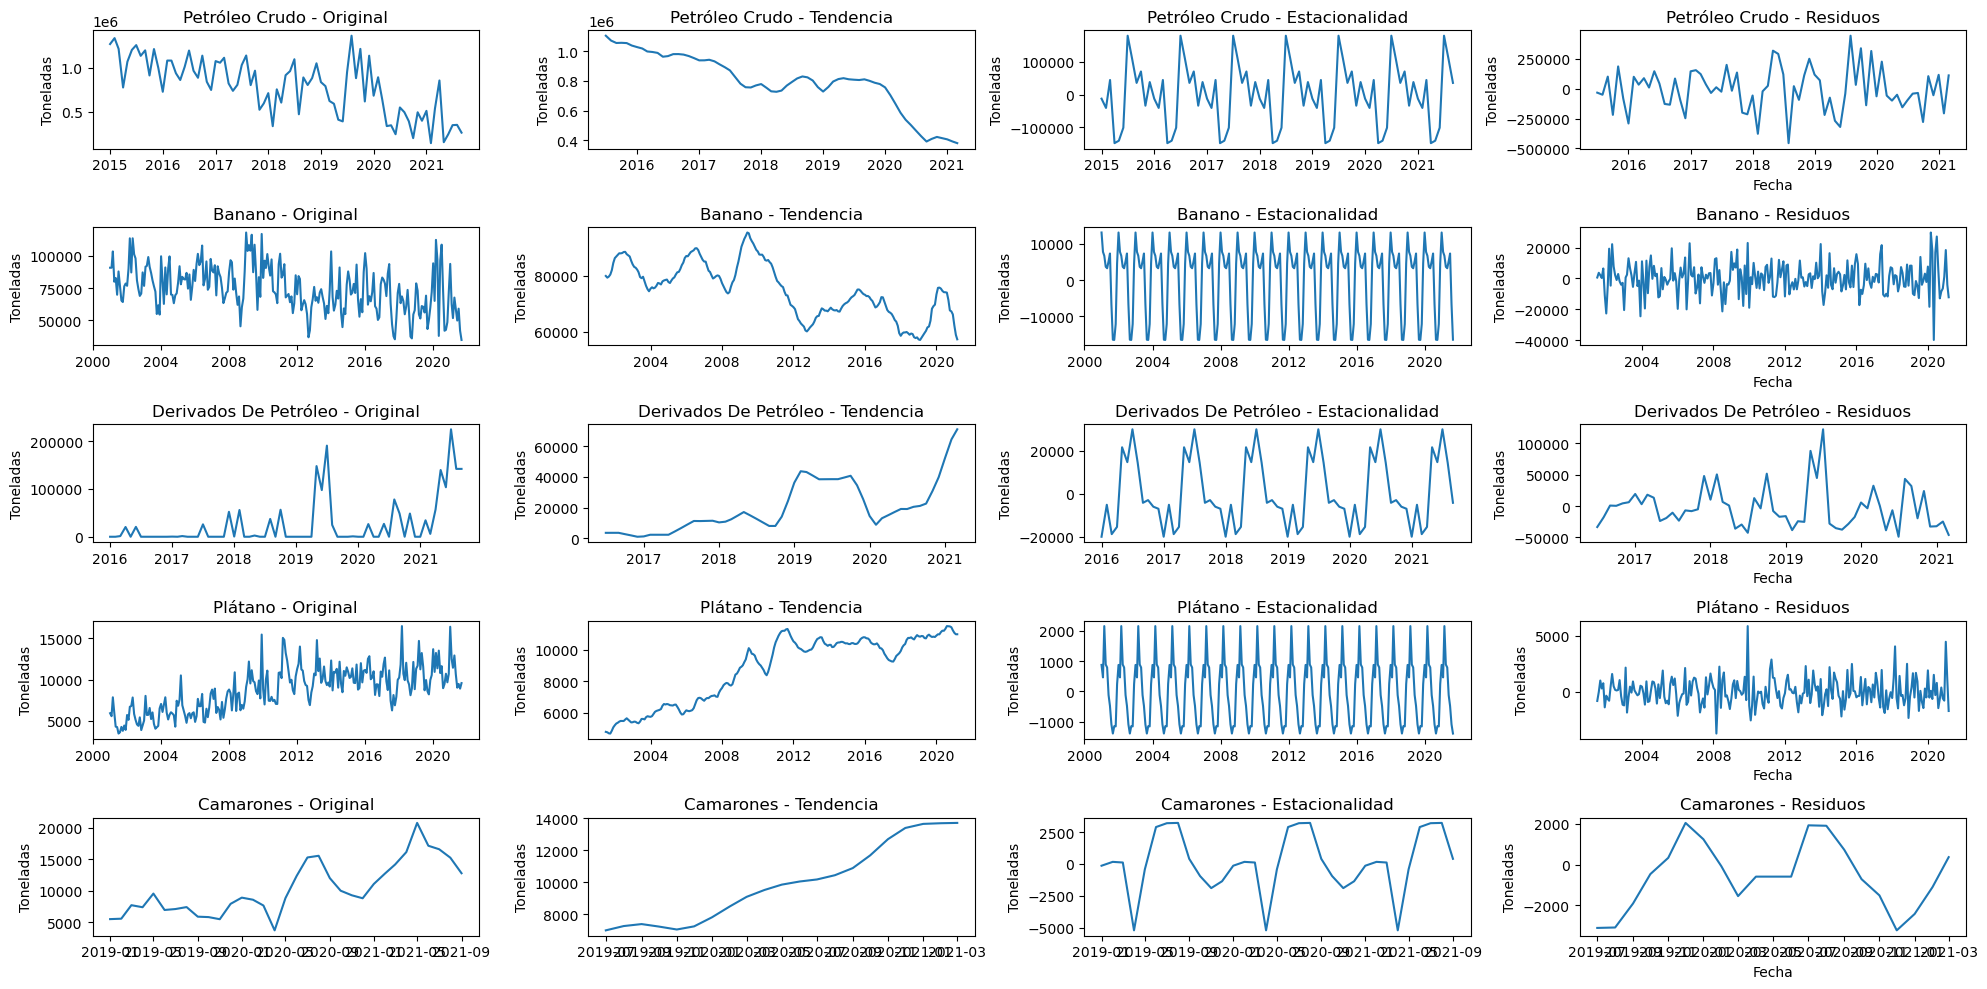

In [55]:
#| label: fig-descompose_cut
#| fig-cap: Descomposición de componentes cortados


# Creación de subgráficos

# para clarificar la tendencia
cortes = ['2015', '2001', '2016', '2001', '2019']

fig, axs = plt.subplots(5, 4, figsize=(20, 10))

for i, producto, corte in zip(range(5), top_5_productos, cortes):
    # Filtrar el producto y agregar por mes
    data_producto = (dfm[(dfm['Producto Principal (Nivel 4)'] == producto)]
                     .resample('M')['Toneladas'].sum())[corte:]

    # Ajusta el índice para que sea el inicio de cada mes
    data_producto.index = data_producto.index.to_period('M').to_timestamp()
    
    # Descomposición estacional
    descomposicion = seasonal_decompose(data_producto, model='additive')
    
    # Graficar descomposición
    axs[i, 0].plot(data_producto)
    axs[i, 0].set_title(f'{producto} - Original')
    axs[i, 0].set_ylabel('Toneladas')
    
    axs[i, 1].plot(descomposicion.trend)
    axs[i, 1].set_title(f'{producto} - Tendencia')
    axs[i, 1].set_ylabel('Toneladas')
    
    axs[i, 2].plot(descomposicion.seasonal)
    axs[i, 2].set_title(f'{producto} - Estacionalidad')
    axs[i, 2].set_ylabel('Toneladas')
    
    axs[i, 3].plot(descomposicion.resid)
    axs[i, 3].set_title(f'{producto} - Residuos')
    axs[i, 3].set_ylabel('Toneladas')
    axs[i, 3].set_xlabel('Fecha')

    xmin = data_producto.index.min()
    xmax = data_producto.index.max()

        
# Ajuste de espaciado y visualización
plt.tight_layout()
plt.show()

# Selección del modelo

Dado que se está trabajando con un problema de series de tiempo, un buen punto de partida podría ser utilizar modelos de series de tiempo clásicos como el modelo ARIMA (AutoRegressive Integrated Moving Average) o el modelo SARIMA (Seasonal AutoRegressive Integrated Moving Average), que tiene en cuenta la estacionalidad de los datos.

Otra opción sería utilizar el modelo Prophet desarrollado por Facebook, que es muy efectivo para tratar datos de series de tiempo con patrones estacionales y tendencias.

También se puede considerar el uso de modelos de aprendizaje profundo como las redes neuronales recurrentes (RNN), especialmente las unidades de memoria a corto plazo (LSTM) y las redes de memoria de plazo corto (GRU), que son especialmente adecuadas para trabajar con datos secuenciales y series de tiempo.

## El Modelo Prophet

Prophet es un marco de código abierto de Meta utilizado para enmarcar y predecir series temporales. Se centra en un modelo aditivo en el cual las tendencias no lineales se ajustan con estacionalidades diarias, semanales y anuales, además de efectos adicionales de días festivos. Prophet es eficiente en el manejo de datos faltantes y cambios en las tendencias, y generalmente maneja bien los valores atípicos. También permite acumular variables exógenas en el modelo. [@vishwas2020hands]

Prophet utiliza un modelo de serie temporal descomponible:
$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

Donde:

- **y(t)** es la predicción en el tiempo **`t`**.
- **g(t)** representa la función de tendencia que modela cambios no lineales a lo largo del tiempo.
- **s(t)** es la función de estacionalidad que captura patrones periódicos (diarios, semanales y anuales) en los datos.
- **h(t)** es la función que modela los efectos de los días festivos o eventos especiales.
- **$\epsilon_t$** es el término de error en el tiempo **`t`**.

A diferencia del modelo ARIMA, Prophet no considera la dependencia temporal de los datos y es más como ajustar una curva a los datos. Aunque esto puede generar una pérdida de información predictiva, el modelo es flexible y puede manejar múltiples períodos estacionales y tendencias cambiantes. Además, es robusto ante valores atípicos y datos faltantes. Para abordar múltiples períodos estacionales, Prophet utiliza la serie de Fourier para modelar varios efectos periódicos. [@peixeiro2022time]

$$s\left ( t \right ) = \sum_{n=1}^{N}\left ( a_{n}\cos \left ( \frac{2\pi nt}{P} \right ) + b_{n}\sin \left ( \frac{2\pi nt}{P} \right )\right )$$

## Entrenamiento y validación del modelo

Cuando se trabaja con series de tiempo, es importante tener en cuenta la naturaleza secuencial de los datos al dividirlos en conjuntos de entrenamiento y prueba. A diferencia de otros tipos de datos, no es adecuado dividir las series de tiempo de forma aleatoria, ya que esto podría romper la secuencia temporal y hacer que el modelo no capte las dependencias temporales adecuadamente.

::: {.callout-tip}
En lugar de dividir los datos aleatoriamente, se recomienda dividirlos de manera secuencial. Por lo general, esto implica utilizar una parte inicial de la serie de tiempo para el entrenamiento y una parte posterior para la prueba. Esto asegura que el conjunto de entrenamiento contenga todos los datos anteriores al conjunto de prueba, manteniendo la secuencia temporal.
:::

Esta forma de dividir los datos garantiza que el conjunto de entrenamiento contenga todos los datos anteriores al conjunto de prueba, preservando la secuencia temporal y evitando que el modelo tenga acceso a información futura durante el entrenamiento.

In [59]:
def generar_modelo(producto, frecuencia='M', inicio=None, sizetest=12, periodos=12):
    # Crear el dataframe
    dfa = df.reset_index().groupby([pd.Grouper(key='Fecha', freq=frecuencia), 
                              'Producto Principal (Nivel 4)', 'Tradicional/No tradicional', 'No Petrolero/Petrolero']).sum().reset_index(level=[1,2,3])

    df_producto = (dfa[(dfa['Producto Principal (Nivel 4)'] == producto)]
                         .resample(frecuencia)[['Toneladas']].sum())[inicio:].reset_index()

    #Renombrando las columnas
    df_producto.columns = ['ds', 'y']

    # Dividir los datos en entrenamiento y prueba
    
    train_df = df_producto.iloc[:-sizetest]  # Todos los datos excepto los últimos 12 meses
    test_df = df_producto.iloc[-sizetest:]   # Los últimos 12 meses

    # Entrenar el modelo Prophet con los datos de entrenamiento
    model = Prophet(seasonality_prior_scale=1)
    model.fit(train_df)

    # Realizar predicciones para el período de prueba
    future = model.make_future_dataframe(periods=sizetest, freq=frecuencia, include_history=False)
    forecast = model.predict(future)

    #########
    y_test = test_df.y
    y_pred = forecast['yhat']

    # Asumiendo que y_test son los valores reales y y_pred son las predicciones del modelo
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}")

    ###########

    # Graficar los datos reales y las predicciones
    plt.figure(figsize=(12, 6))
    plt.plot(df_producto['ds'], df_producto['y'], label='Datos reales', color='gray')
    plt.plot(test_df['ds'], forecast['yhat'], label='Predicción del entrenamiento', color='green')

    # Hacer predicciones para los siguientes 12 meses a partir de la fecha final del dataset
    model2 = Prophet(seasonality_prior_scale=1)
    model2.fit(df_producto)

    future_12_months = model2.make_future_dataframe(periods=periodos, freq=frecuencia, include_history=False)
    forecast_12_months = model2.predict(future_12_months)
    
    # Graficar las predicciones para los siguientes 12 meses
    plt.plot(forecast_12_months['ds'], forecast_12_months['yhat'], label='Predicción para el siguiente año', color='red')

    # Configurar los elementos del gráfico
    plt.xlabel('')
    plt.ylabel('Toneladas')
    plt.title(f'{producto}: Datos reales vs Predicciones')
    plt.legend()
    #plt.savefig(f'{producto}.png')
    plt.show()
    print(forecast_12_months[['ds', 'yhat']])
    #forecast_12_months[['ds', 'yhat']].to_excel(f'{producto}.xlsx')

# Resultados y comunicación

10:02:17 - cmdstanpy - INFO - Chain [1] start processing
10:02:17 - cmdstanpy - INFO - Chain [1] done processing
10:02:18 - cmdstanpy - INFO - Chain [1] start processing


MAE: 486738.74
MSE: 419594396854.40
RMSE: 647761.06
R²: 0.32


10:02:18 - cmdstanpy - INFO - Chain [1] done processing


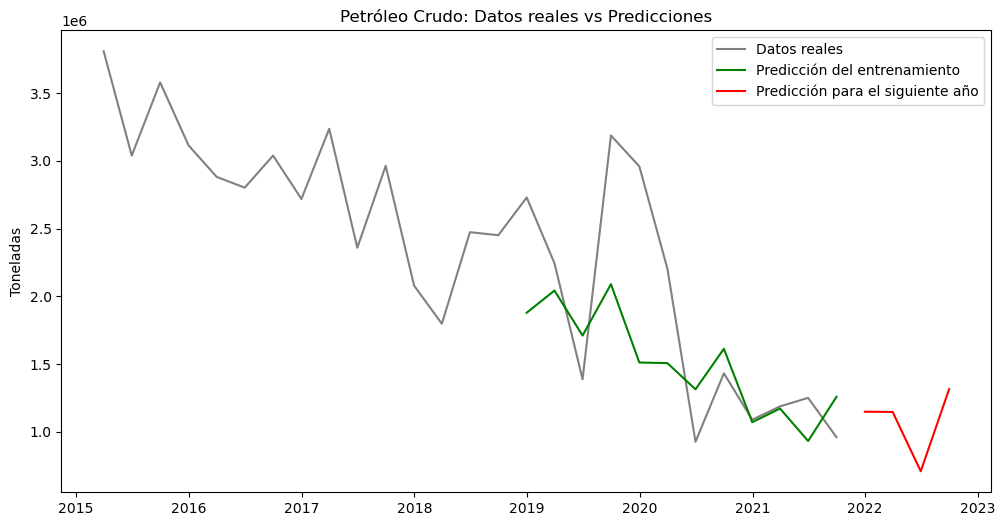

          ds         yhat
0 2021-12-31 1,147,771.79
1 2022-03-31 1,146,011.55
2 2022-06-30   707,670.85
3 2022-09-30 1,314,303.22


In [62]:
producto = 'Petróleo Crudo'
frecuencia = 'Q'
inicio = '2015'
tamano_prueba = 12
periodos = 4

generar_modelo(producto, frecuencia, inicio, tamano_prueba, periodos)

10:02:22 - cmdstanpy - INFO - Chain [1] start processing
10:02:22 - cmdstanpy - INFO - Chain [1] done processing
10:02:22 - cmdstanpy - INFO - Chain [1] start processing
10:02:22 - cmdstanpy - INFO - Chain [1] done processing


MAE: 10146.62
MSE: 140768970.74
RMSE: 11864.61
R²: 0.39


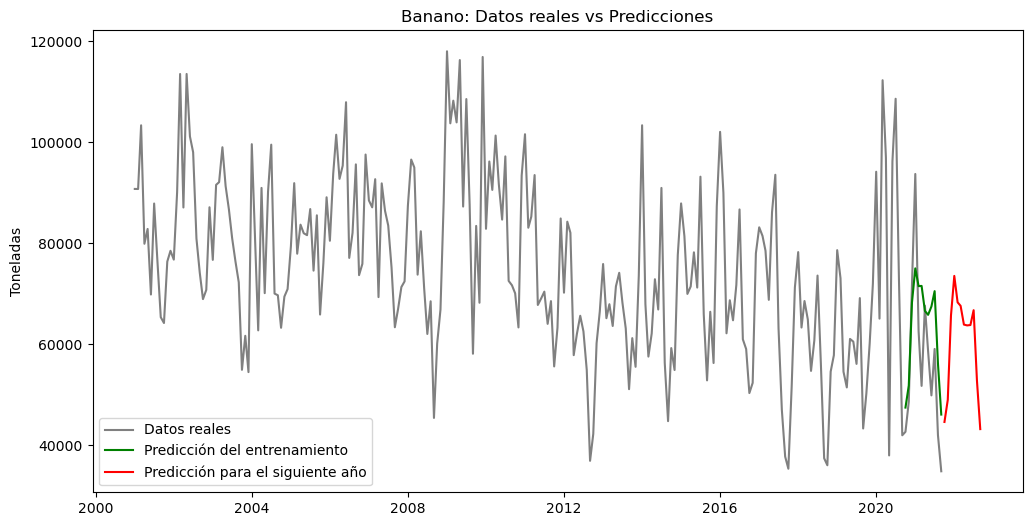

           ds      yhat
0  2021-10-01 44,655.36
1  2021-11-01 49,030.52
2  2021-12-01 65,732.96
3  2022-01-01 73,566.37
4  2022-02-01 68,335.96
5  2022-03-01 67,644.05
6  2022-04-01 63,931.00
7  2022-05-01 63,769.45
8  2022-06-01 63,843.29
9  2022-07-01 66,778.01
10 2022-08-01 52,860.35
11 2022-09-01 43,241.06


In [64]:
producto = 'Banano'
frecuencia = 'MS'
inicio = '2001'
tamano_prueba = 12
periodos = 12

generar_modelo(producto, frecuencia, inicio, tamano_prueba, periodos)

10:02:27 - cmdstanpy - INFO - Chain [1] start processing
10:02:27 - cmdstanpy - INFO - Chain [1] done processing
10:02:27 - cmdstanpy - INFO - Chain [1] start processing
10:02:27 - cmdstanpy - INFO - Chain [1] done processing


MAE: 46633.74
MSE: 3123458739.73
RMSE: 55887.91
R²: 0.38


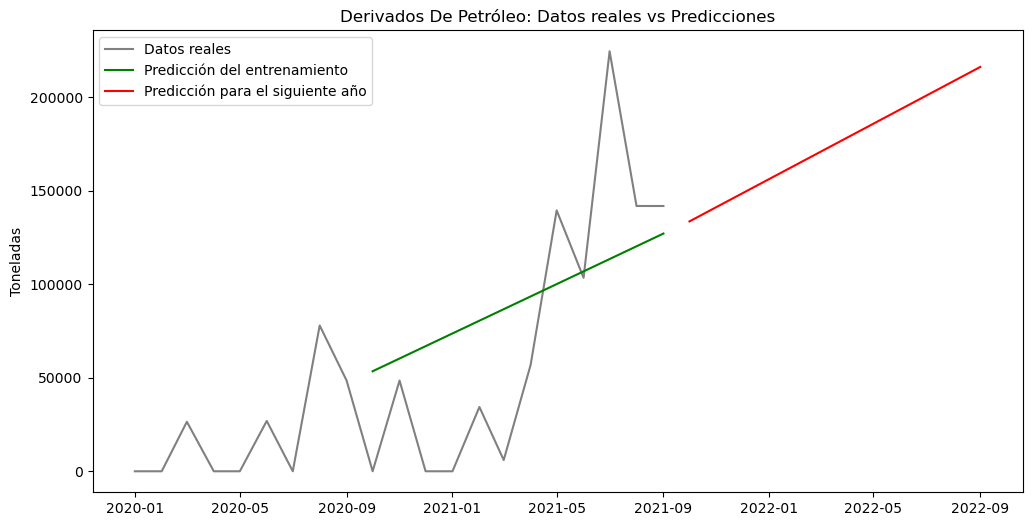

           ds       yhat
0  2021-10-01 133,636.52
1  2021-11-01 141,279.05
2  2021-12-01 148,675.04
3  2022-01-01 156,317.56
4  2022-02-01 163,960.09
5  2022-03-01 170,863.01
6  2022-04-01 178,505.54
7  2022-05-01 185,901.53
8  2022-06-01 193,544.06
9  2022-07-01 200,940.05
10 2022-08-01 208,582.58
11 2022-09-01 216,225.10


In [66]:
producto = 'Derivados De Petróleo'
frecuencia = 'MS'
inicio = '2020'
tamano_prueba = 12
periodos = 12

generar_modelo(producto, frecuencia, inicio, tamano_prueba, periodos)

10:02:28 - cmdstanpy - INFO - Chain [1] start processing
10:02:28 - cmdstanpy - INFO - Chain [1] done processing
10:02:28 - cmdstanpy - INFO - Chain [1] start processing
10:02:29 - cmdstanpy - INFO - Chain [1] done processing


MAE: 1059.12
MSE: 2178688.74
RMSE: 1476.04
R²: 0.38


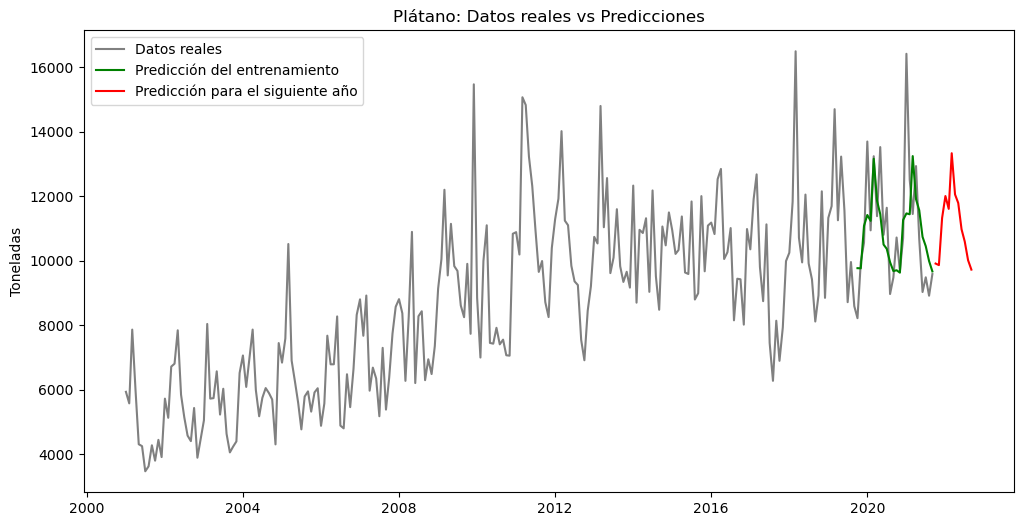

           ds      yhat
0  2021-10-01  9,910.72
1  2021-11-01  9,862.68
2  2021-12-01 11,323.60
3  2022-01-01 12,003.12
4  2022-02-01 11,606.01
5  2022-03-01 13,329.57
6  2022-04-01 12,052.21
7  2022-05-01 11,786.42
8  2022-06-01 10,972.20
9  2022-07-01 10,592.09
10 2022-08-01 10,014.52
11 2022-09-01  9,722.74


In [68]:
producto = 'Plátano'
frecuencia = 'MS'
inicio = '2001'
tamano_prueba = 24
periodos = 12

generar_modelo(producto, frecuencia, inicio, tamano_prueba, periodos)

10:02:33 - cmdstanpy - INFO - Chain [1] start processing
10:02:33 - cmdstanpy - INFO - Chain [1] done processing
10:02:33 - cmdstanpy - INFO - Chain [1] start processing


MAE: 2321.13
MSE: 8163479.85
RMSE: 2857.18
R²: 0.32


10:02:33 - cmdstanpy - INFO - Chain [1] done processing


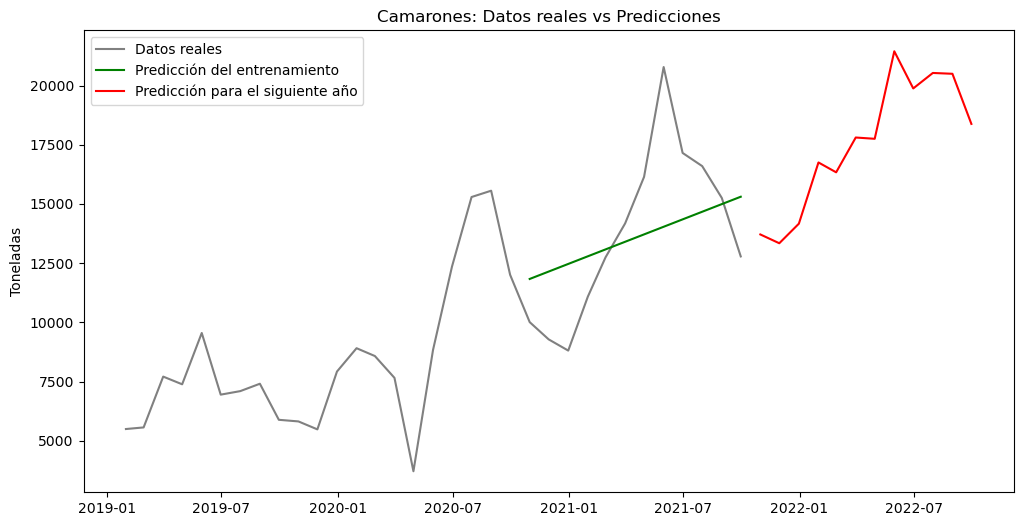

           ds      yhat
0  2021-10-31 13,711.40
1  2021-11-30 13,339.75
2  2021-12-31 14,166.41
3  2022-01-31 16,751.51
4  2022-02-28 16,335.40
5  2022-03-31 17,805.29
6  2022-04-30 17,750.83
7  2022-05-31 21,447.06
8  2022-06-30 19,877.97
9  2022-07-31 20,531.44
10 2022-08-31 20,496.65
11 2022-09-30 18,379.33


In [70]:
producto = 'Camarones'
frecuencia = 'M'
inicio = '2019'
tamano_prueba = 12
periodos = 12

generar_modelo(producto, frecuencia, inicio, tamano_prueba, periodos)

# Afinamiento de hiperparámetros

## Incorporación del regresor `precio` y ajuste de la frecuencia de los datos

In [73]:
def generar_modelo_regresor(producto, frecuencia='M', inicio=None, sizetest=12, periodos=12):
    # Crear el dataframe
    dfa = df.reset_index().groupby([pd.Grouper(key='Fecha', freq=frecuencia), 
                              'Producto Principal (Nivel 4)', 'Tradicional/No tradicional', 'No Petrolero/Petrolero']).sum().reset_index(level=[1,2,3])

    df_producto = (dfa[(dfa['Producto Principal (Nivel 4)'] == producto)]
                         .resample(frecuencia)[['Toneladas', 'Precio Unitario']].sum())[inicio:].reset_index()

    #Renombrando las columnas
    df_producto.rename(columns={'Fecha': 'ds', 'Toneladas': 'y'}, inplace=True)

    # Dividir los datos en entrenamiento y prueba
    train_df = df_producto.iloc[:-sizetest]  # Todos los datos excepto los últimos 12 meses
    test_df = df_producto.iloc[-sizetest:]   # Los últimos 12 meses

    # Entrenar el modelo Prophet con los datos de entrenamiento
    model = Prophet(seasonality_prior_scale=1)
    model.add_regressor('Precio Unitario')
    model.fit(train_df)

    # Realizar predicciones para el período de prueba
    future = model.make_future_dataframe(periods=sizetest + periodos, freq=frecuencia, include_history=False)
    future['Precio Unitario'] = df_producto['Precio Unitario'].iloc[-(sizetest + periodos):].values
    forecast = model.predict(future)

    # Calcular métricas de error
    y_test = test_df.y
    y_pred = forecast['yhat'][:sizetest]

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}")

    # Graficar los datos reales y las predicciones
    plt.figure(figsize=(12, 6))
    plt.plot(df_producto['ds'], df_producto['y'], label='Datos reales', color='gray')
    plt.plot(test_df['ds'], y_pred, label='Predicción del entrenamiento', color='green')
    plt.plot(forecast['ds'][sizetest:], forecast['yhat'][sizetest:], label='Predicción para el siguiente año', color='red')

    plt.xlabel('')
    plt.ylabel('Toneladas')
    plt.title(f'{producto}: Datos reales vs Predicciones')
    plt.legend()
    plt.show()

10:02:39 - cmdstanpy - INFO - Chain [1] start processing
10:02:39 - cmdstanpy - INFO - Chain [1] done processing


MAE: 1641.69
MSE: 10129891.45
RMSE: 3182.75
R²: 0.81


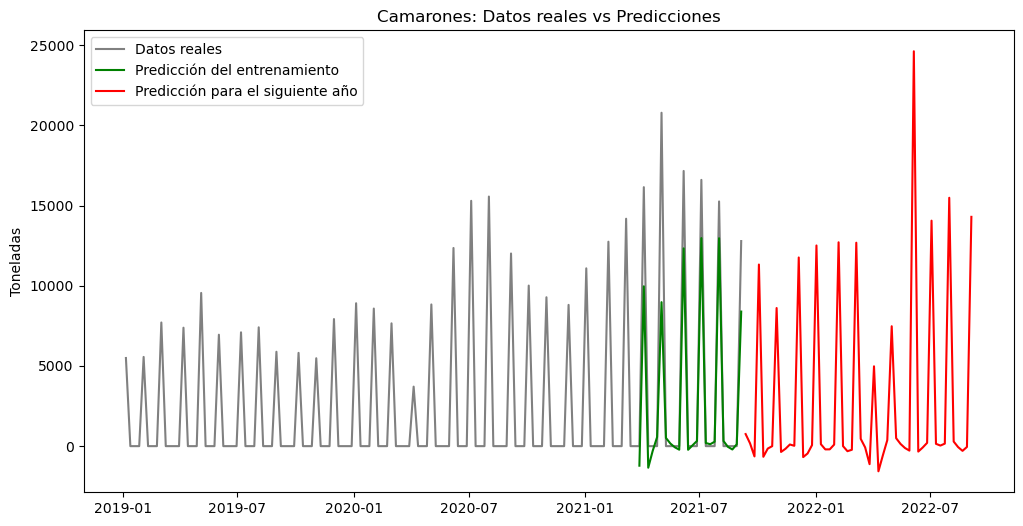

In [75]:
producto = 'Camarones'
frecuencia = 'W'
inicio = '2019'
tamano_prueba = 24
periodos = 52

generar_modelo_regresor(producto, frecuencia, inicio, tamano_prueba, periodos)

10:02:42 - cmdstanpy - INFO - Chain [1] start processing
10:02:42 - cmdstanpy - INFO - Chain [1] done processing


MAE: 981.29
MSE: 1954889.26
RMSE: 1398.17
R²: 0.90


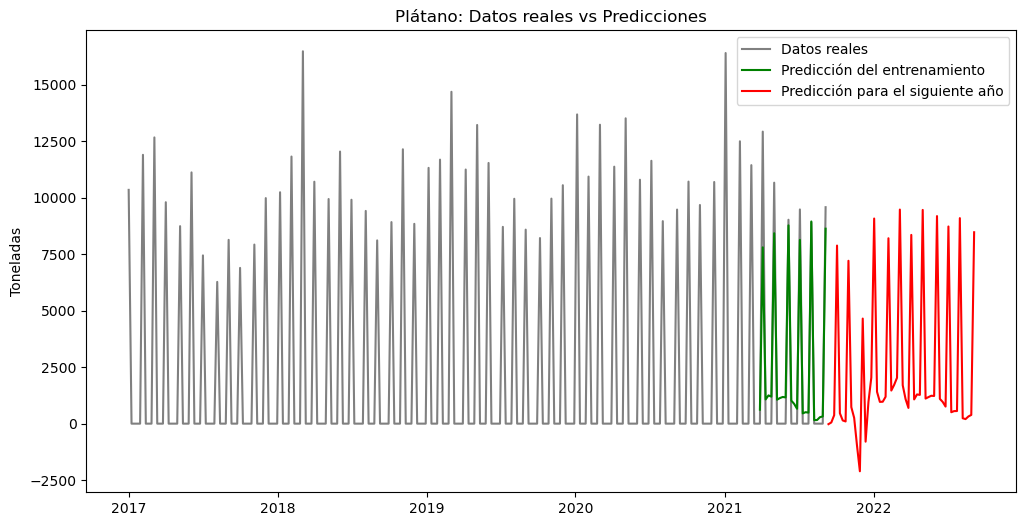

In [77]:
producto = 'Plátano'
frecuencia = 'W'
inicio = '2017'
tamano_prueba = 24
periodos = 52

generar_modelo_regresor(producto, frecuencia, inicio, tamano_prueba, periodos)

10:02:46 - cmdstanpy - INFO - Chain [1] start processing
10:02:46 - cmdstanpy - INFO - Chain [1] done processing


MAE: 6470.12
MSE: 65786055.97
RMSE: 8110.86
R²: 0.88


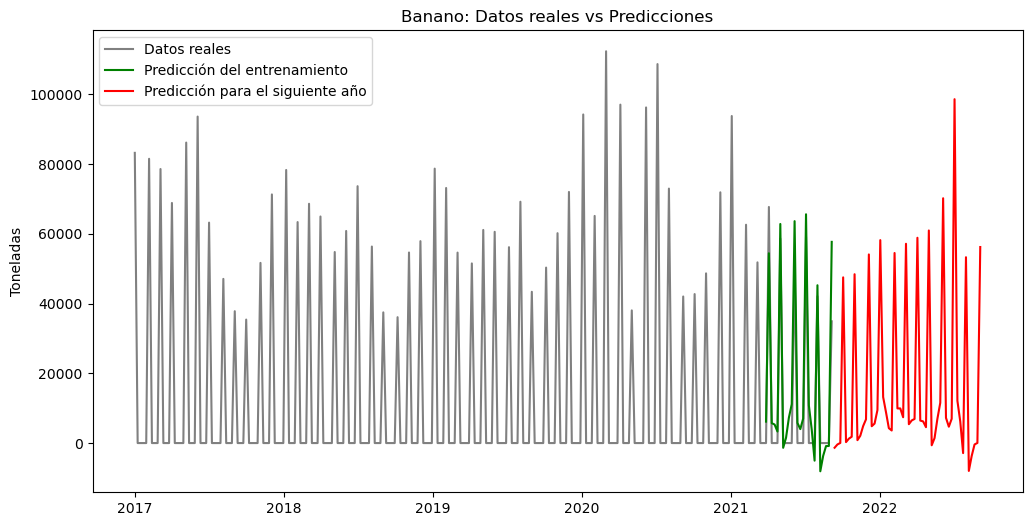

In [79]:
producto = 'Banano'
frecuencia = 'W'
inicio = '2017'
tamano_prueba = 24
periodos = 52

generar_modelo_regresor(producto, frecuencia, inicio, tamano_prueba, periodos)

# Conclusiones

Un coeficiente de determinación (R²) de 0.38 indica que aproximadamente el 38% de la variabilidad en los datos de exportación de los productos puede ser explicada por el modelo. En otras palabras, los modelos pueden explicar una parte de la variación en las exportaciones, pero no la mayoría de ella. Un R² de 0.38 puede considerarse relativamente bajo en algunos contextos, lo que sugiere que los modelo podrían no ser lo suficientemente precisos para hacer predicciones muy confiables. Sin embargo, la calidad de un R² depende del campo de estudio y del problema en cuestión. En algunos casos, un R² de 0.38 podría ser aceptable, especialmente si no hay muchos datos disponibles o si los datos son muy ruidosos.

Los modelos de los productos no petroleros, mejoraron significativamente al incluir la variable `Precio Unitario` y cambiar la frecuencia a `Semanal`.

Inclusión del precio unitario como regresor
: Al agregar una variable adicional al modelo, se proporciona información adicional que puede ayudar a explicar la variabilidad en los datos. En este caso, el precio unitario puede estar relacionado con las exportaciones y al incluirlo como regresor, el modelo puede capturar mejor la relación entre las variables. Esto puede mejorar significativamente la precisión de las predicciones.

Cambio de frecuencia de mensual a semanal
: Al cambiar la frecuencia de los datos de mensual a semanal, se proporciona más puntos de datos al modelo, lo que puede ayudar a capturar mejor las tendencias y patrones en los datos. Además, al aumentar la granularidad de los datos, es posible que ahora se esté capturando información estacional o de tendencia que antes no era evidente a nivel mensual. Esto también puede contribuir a la mejora en el rendimiento del modelo.

# Recomendaciones

Para mejorar el modelo de predicción de exportaciones se podría intentar lo siguiente:


- **Incluir más variables**: Si hay otras variables relevantes que puedan afectar las exportaciones, como datos económicos, factores políticos, precios de productos relacionados, entre otros, probar incluirlos en el modelo para ver si mejora su precisión.

 - **Incorporar información de retrasos temporales**: Algunos modelos de series de tiempo, como ARIMA o modelos de vectores autorregresivos (VAR), utilizan información de retrasos temporales (lag) para capturar la dependencia temporal en los datos. Incorporar estos retrasos podría mejorar la precisión del modelo.

- **Probar diferentes técnicas de modelado**: No todos los modelos funcionan igual de bien para cada conjunto de datos. Prueba con diferentes técnicas de modelado, como modelos de regresión, ARIMA, modelos de estado-espacio, entre otros, para ver cuál funciona mejor en el problema específico.

- **Validación cruzada**: Utilizar validación cruzada para evaluar el rendimiento del modelo en diferentes conjuntos de datos de entrenamiento y prueba. Esto ayudará a comprender cómo de generalizable es el modelo y si es probable que funcione bien en datos futuros no vistos.

- **Sintonizar hiperparámetros**: Algunos modelos, como Prophet o modelos basados en machine learning, tienen hiperparámetros que pueden afectar su rendimiento. Realizar una búsqueda en el espacio de hiperparámetros para encontrar la mejor combinación que mejore la precisión del modelo.

- **Analizar residuos**: Examinar los residuos del modelo (errores de predicción) para verificar si hay patrones no capturados por el modelo. Si se encuentra patrones en los residuos, podría ser una señal de que el modelo no está capturando toda la información disponible en los datos.

Mejorar un modelo de predicción puede ser un proceso iterativo y es posible que se tenga que probar varias sugerencias o combinarlas para lograr una mejora significativa en el rendimiento del modelo.

# Referencias

::: {#refs}
:::